In [1]:
from pathlib import Path
import sys
import math

planning_path = Path('.').absolute().parents[0] / 'cloud_auto_park'
print(planning_path)

sys.path.append(str(planning_path))

from trajectory_utils import *


/project/project/sim_ws/src/digital_twin/cloud_auto_park/cloud_auto_park


In [10]:
x_sep = 5.0
y_sep = 4.5
obb_1 = OrientedBoundingBox(x_sep, y_sep, 4.0, 2.0, math.pi/2)
obb_2 = OrientedBoundingBox(x_sep + 6.0, y_sep, 4.0, 2.0, math.pi/2)
wall = OrientedBoundingBox(5.0, -4.0, 12.0, 1.0, 0.0)
obstacles = [obb_1, obb_2, wall]
# obstacles = [obb_1, obb_2]
desired_pose = OrientedBoundingBox(x_sep + 3.0, y_sep, 4.0, 2.0, math.pi/2)


In [11]:
traj_optimizer = TrajectoryOptimizer(method='BFGS')
traj_optimizer.generate_optimal_trajectory(desired_pose, obstacles)


/usr/local/lib/python3.8/dist-packages/scipy/optimize/_minimize.py:569: RuntimeWarning: Method BFGS cannot handle bounds.
  warn('Method %s cannot handle bounds.' % method,


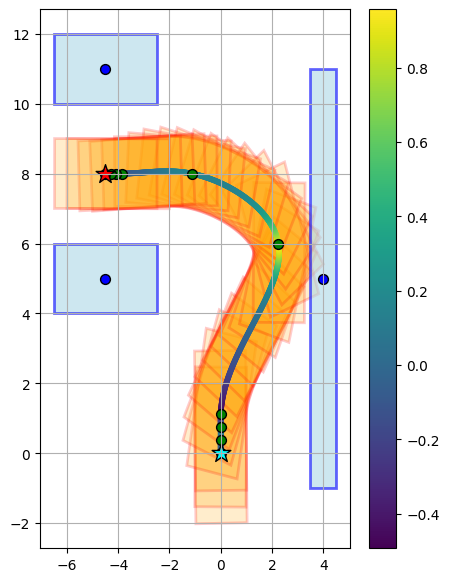

In [12]:
plot_desired_path(traj_optimizer.initial_traj, obstacles, num_intermediate_ego=30)


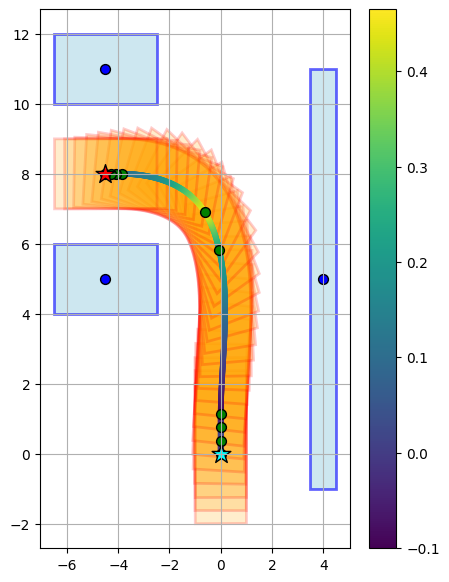

In [13]:
plot_desired_path(traj_optimizer.optimized_traj, obstacles, num_intermediate_ego=30)


In [23]:
# playground to get more intuition as to how b spline interpolation works...
import numpy as np
from scipy import interpolate

control_points = np.array([[0, 0],[0.5, 1],[1, 2],[3, 2],[3.5, 1],[4, 0]])

distances = np.cumsum(np.sqrt(np.square(np.diff(control_points[:,0])) + np.square(np.diff(control_points[:,1]))))
distances /= distances[-1]
print(distances)

tck,u = interpolate.splprep([control_points[:,0], control_points[:,1]], s=0)
# tck = interpolate.splrep(control_points[:,0], control_points[:,1])

print(f'initial data points: {control_points}')
print(f'knot vector: {tck[0]}')
print(f'control points: {tck[1]}')
print(f'degree: {tck[2]}')
print(u)

u_initial_sample = np.arange(0, 1.01, 0.005)
out = interpolate.splev(u_initial_sample, tck)
# path_length = get_path_length(out)
# u_final_sample = np.arange(0, 1.0, (speed_mps / sample_rate_hz) / path_length)
# path = interpolate.splev(u_final_sample, tck)
# first_derivative = interpolate.splev(u_final_sample, tck, der=1)
# second_derivative = interpolate.splev(u_final_sample, tck, der=2)
# headings = np.arctan2(first_derivative[1], first_derivative[0])
# curvature = (first_derivative[0] * second_derivative[1] - first_derivative[1] * second_derivative[0]) / np.power(np.square(first_derivative[0]) + np.square(first_derivative[1]), 1.5)
# return path, headings, curvature


[0.17274575 0.3454915  0.6545085  0.82725425 1.        ]
initial data points: [[0.  0. ]
 [0.5 1. ]
 [1.  2. ]
 [3.  2. ]
 [3.5 1. ]
 [4.  0. ]]
knot vector: [0.        0.        0.        0.        0.3454915 0.6545085 1.
 1.        1.        1.       ]
control points: [array([2.06559327e-17, 5.50825281e-01, 3.58255693e-01, 3.64174431e+00,
       3.44917472e+00, 4.00000000e+00]), array([2.32379243e-17, 4.85668648e-01, 2.43439524e+00, 2.43439524e+00,
       4.85668648e-01, 0.00000000e+00])]
degree: 3
[0.         0.17274575 0.3454915  0.6545085  0.82725425 1.        ]
